# 05 · Decomposing hysteresis: trust learning vs individual stubbornness

Notebooks 03 and 04 framed lock-in around the asymmetric-KL "cost of mind-change"
$\lambda$. The current paper draft (2026-05-13) restructures this: hysteresis
has three independent sources (PDF §3),

  (i)  coupling-induced lag      — linear filter, *no* hysteresis (just inertia);
  (ii) trust accumulation        — dominant; hysteresis even at $\lambda = 0$;
  (iii) individual stubbornness  — second-order amplifier.

The new Proposition 1 requires *both* $\lambda = 0$ *and* $\Gamma$ frozen for
symmetric reversal. The core empirical claim (PDF E1) is a $2 \times 2$
factorial over $(\lambda \in \{0, >0\}) \times (\Gamma \in \{\text{frozen},
\text{learning}\})$, predicting that **trust learning alone produces more
hysteresis than $\lambda$ alone**.

The trust update underlying this notebook is the Gamma-conjugate Bayesian
form from PDF §2.3 — exponential forgetting at rate $\rho$, with state
$(\alpha_{ij}, \beta_{ij})$ per edge and $\gamma_{ij} = \alpha_{ij}/\beta_{ij}$.
`ModelConfig.trust_learning=False` freezes $(\alpha, \beta)$ for the ablation
conditions.

## §0 · Protocol and helpers

Single-feature world. Forward-reverse shock identical to notebook 04:

  warmup 30 steps at $s^* = 0$  →  shock to 1 for 20 steps  →
  shock back to 0 for 20 steps.

For each $(\lambda, \text{trust\_learning})$ pair we run one shock cycle
on $N = 80$ Watts–Strogatz agents and read off:

- **loop area** (PDF headline metric): shoelace area enclosed by the
  trajectory in the $(s^*, \bar\sigma(C))$ phase plane.
- **lock-in fraction** $R/A$ from notebook 04: endpoint residual divided
  by shock-response amplitude. Continuous, $\in [0, 1]$.

We expect loop-area and $R/A$ to tell the same story two ways.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp
import equinox as eqx

from src import build, ModelConfig, EnvConfig, EvolutionRegime

sns.set_theme(context='notebook', style='whitegrid')


def shoelace_area(xs: np.ndarray, ys: np.ndarray) -> float:
    """Auto-closed polygon shoelace area (returns absolute value)."""
    xs_c = np.concatenate([xs, xs[:1]])
    ys_c = np.concatenate([ys, ys[:1]])
    return 0.5 * float(np.abs(np.sum(xs_c[:-1] * ys_c[1:] - xs_c[1:] * ys_c[:-1])))


def run_shock_cycle(*, lambda_val: float, trust_learning: bool,
                    trust_rho: float = 1.0,
                    n_agents: int = 80, warm_T: int = 40, leg_T: int = 40,
                    d_mean: float = 0.95,
                    gamma_env: float = 1.0, seed: int = 0):
    """One forward-reverse shock cycle. Returns (sig_traj, x_traj, marks).

    Default params chosen to surface social-channel effects:
      - gamma_env=1.0   -> sigmoid evidence ~0.73, env informative but not overwhelming
      - d_mean=0.95     -> heavy social weight; (1-d)*p_env contributes ~5%
      - trust_rho=1.0   -> no forgetting; trust accumulates over the full run
      - leg_T=40        -> 40 forward + 40 reverse for clean trust accumulation
    """
    d_a = max(0.5, 10.0 * d_mean)
    d_b = max(0.5, 10.0 * (1.0 - d_mean))

    cfg = ModelConfig(
        n_agents=n_agents, n_features=1,
        lambda_dist=('constant', {'value': float(lambda_val)}),
        lambda_scope='per_agent',
        gamma_env=gamma_env,
        delegation_alpha=d_a, delegation_beta=d_b,
        network_kind='watts_strogatz', mean_degree=4, rewiring_p=0.1,
        trust_rho=trust_rho, trust_learning=trust_learning,
        seed=seed,
    )
    env_cfg = EnvConfig(
        n_agents=n_agents, n_features=1,
        regime=EvolutionRegime.STATIONARY, stationary_flip_prob=0.0,
        seed=seed + 100,
    )
    env, pop = build(cfg, env_cfg)

    env.s_star[:] = np.array([0], dtype=np.int64)
    sigs, xs = [], []

    def rec(x: int) -> None:
        sigs.append(1.0 / (1.0 + np.exp(-np.asarray(pop.C)[:, 0])))
        xs.append(x)

    rec(0)
    for _ in range(warm_T):
        pop, _ = pop.step(env); rec(0)
    warm_end = len(sigs) - 1
    env.s_star[0] = 1
    for _ in range(leg_T):
        pop, _ = pop.step(env); rec(1)
    fwd_end = len(sigs) - 1
    env.s_star[0] = 0
    for _ in range(leg_T):
        pop, _ = pop.step(env); rec(0)
    rev_end = len(sigs) - 1

    return (np.stack(sigs), np.array(xs, dtype=float),
            dict(warm_end=warm_end, fwd_end=fwd_end, rev_end=rev_end))


def lock_in_metrics(sigs: np.ndarray, marks: dict) -> dict:
    pop_mean = sigs.mean(axis=1)
    s0 = pop_mean[marks['warm_end']]
    sp = pop_mean[marks['fwd_end']]
    sm = pop_mean[marks['rev_end']]
    A = sp - s0
    R = sm - s0
    frac = R / A if abs(A) > 1e-6 else 0.0
    return dict(response=float(A), residual=float(R),
                lock_in_frac=float(frac))


# Four conditions of the E1 2x2.
CONDITIONS = [
    dict(label='(a) baseline',    lam=0.0,  learn=False, color='#888888'),
    dict(label='(b) trust-only',  lam=0.0,  learn=True,  color='#117733'),
    dict(label='(c) lambda-only', lam=10.0, learn=False, color='#CC6677'),
    dict(label='(d) both',        lam=10.0, learn=True,  color='#332288'),
]
print('Four E1 conditions:')
for c in CONDITIONS:
    print(f"  {c['label']:20s}  lam={c['lam']:>5g}  trust_learning={c['learn']}")


Four E1 conditions:
  (a) baseline          lam=    0  trust_learning=False
  (b) trust-only        lam=    0  trust_learning=True
  (c) lambda-only       lam=   10  trust_learning=False
  (d) both              lam=   10  trust_learning=True


## §1 · Trajectories per condition

Run each of the four conditions through the same shock protocol. Plot
the population-mean $\bar\sigma(C)$ over time for each. Reading the
four lines side-by-side reveals what each mechanism contributes:

- **(a) baseline** ($\lambda = 0$, $\Gamma$ frozen): linear-filter
  inertia only. $\bar\sigma$ tracks the env up and back, no residual.
- **(b) trust-only** ($\lambda = 0$, $\Gamma$ learning): individuals
  are Bayes-optimal, but trust weights accumulated during the forward
  shock keep biasing the social pool after reversal.
- **(c) $\lambda$-only** ($\lambda = 5$, $\Gamma$ frozen): the C-update
  resists motion symmetrically; some residual lag in both directions
  but the loop should be smaller than (b) per PDF §3.
- **(d) both**: the two costs compound.

C:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:60: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


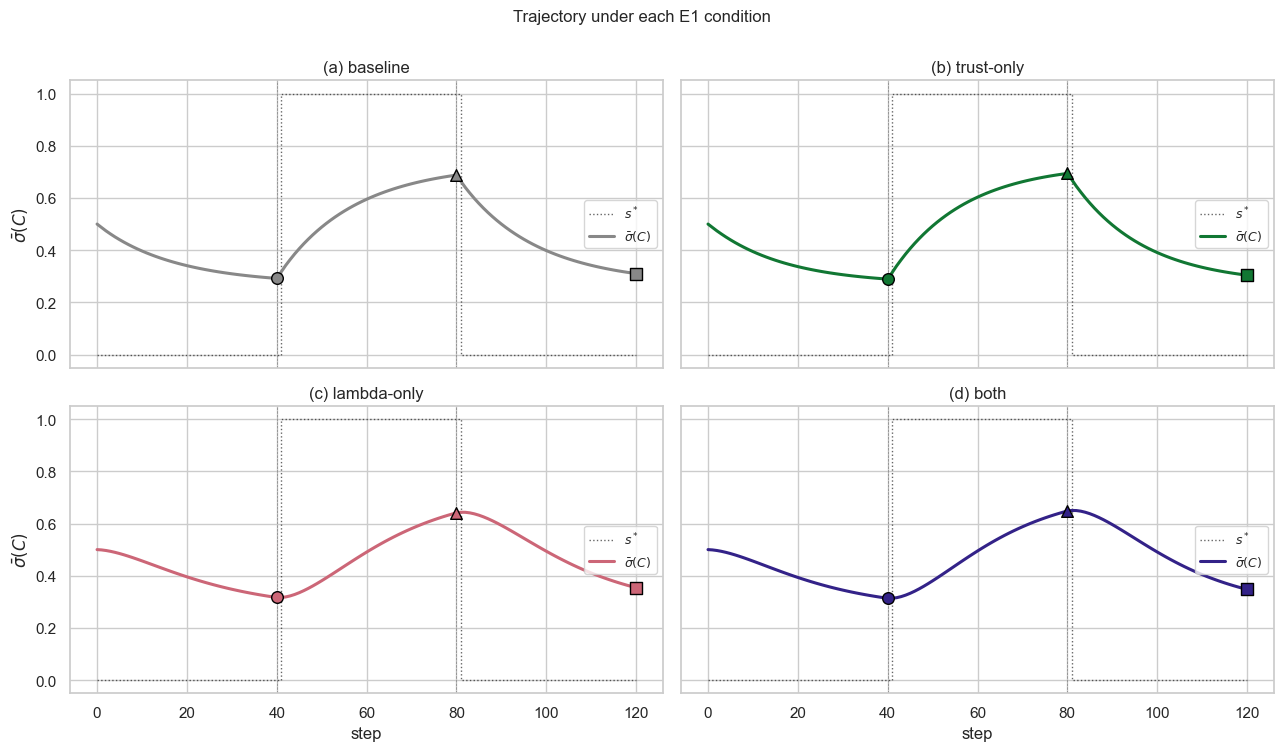

In [2]:
warm_T, leg_T = 40, 40
results = {}
for cond in CONDITIONS:
    sigs, xs, marks = run_shock_cycle(
        lambda_val=cond['lam'], trust_learning=cond['learn'],
        n_agents=80, warm_T=warm_T, leg_T=leg_T,
    )
    results[cond['label']] = (sigs, xs, marks, lock_in_metrics(sigs, marks))

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, cond in zip(axes.flat, CONDITIONS):
    sigs, xs, marks, _ = results[cond['label']]
    steps = np.arange(len(xs))
    y = sigs.mean(axis=1)
    ax.step(steps, xs, where='post', color='black', ls=':', lw=1.0,
            alpha=0.6, label='$s^*$')
    ax.plot(steps, y, color=cond['color'], lw=2.2,
            label=r'$\bar\sigma(C)$')
    for k, marker in [('warm_end', 'o'), ('fwd_end', '^'), ('rev_end', 's')]:
        ax.scatter([marks[k]], [y[marks[k]]], color=cond['color'],
                   edgecolor='black', s=70, marker=marker, zorder=5)
    ax.axvline(marks['warm_end'], ls='--', c='grey', lw=0.5)
    ax.axvline(marks['fwd_end'], ls='--', c='grey', lw=0.5)
    ax.set(ylim=(-0.05, 1.05), title=cond['label'])
    ax.legend(loc='center right', fontsize=9)
for ax in axes[-1]: ax.set_xlabel('step')
for ax in axes[:, 0]: ax.set_ylabel(r'$\bar\sigma(C)$')
fig.suptitle('Trajectory under each E1 condition', y=1.00, fontsize=12)
plt.tight_layout()
plt.show()


## §2 · Phase-space loops

The same four trajectories plotted as loops in $(s^*, \bar\sigma(C))$.
Forward leg in orange, reverse leg in blue. A loop that *closes*
(start = end) carries no path-dependence; an *open* loop quantifies
the unrecovered cost. The enclosed shoelace area is reported per
panel — this is the PDF's headline hysteresis metric.

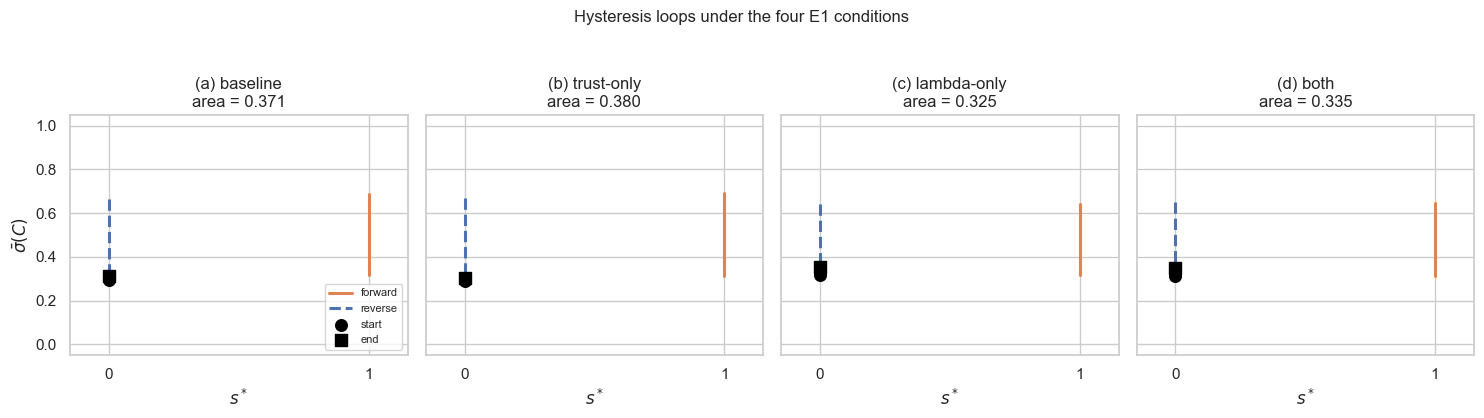

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.0), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    sigs, xs, marks, _ = results[cond['label']]
    y = sigs.mean(axis=1)
    post_warm = np.arange(len(xs)) >= marks['warm_end']
    x_arr = xs[post_warm]
    y_arr = y[post_warm]

    in_fwd = x_arr == 1
    in_rev = (x_arr == 0) & (np.arange(len(x_arr)) > 0)
    # mark a step as 'reverse-leg' if it's a post-warm zero following a one
    leg = np.zeros_like(x_arr, dtype=int)
    seen_one = False
    for k, xv in enumerate(x_arr):
        if xv == 1:
            seen_one = True
            leg[k] = 1
        elif seen_one:
            leg[k] = 2
        else:
            leg[k] = 0

    ax.plot(x_arr[leg == 1], y_arr[leg == 1], color='C1', lw=2.2,
            label='forward')
    ax.plot(x_arr[leg == 2], y_arr[leg == 2], color='C0', lw=2.2, ls='--',
            label='reverse')
    ax.scatter([x_arr[0]], [y_arr[0]], color='black', marker='o',
               s=70, zorder=5, label='start')
    ax.scatter([x_arr[-1]], [y_arr[-1]], color='black', marker='s',
               s=70, zorder=5, label='end')

    area = shoelace_area(x_arr, y_arr)
    ax.set(xlabel='$s^*$', xticks=[0, 1], xlim=(-0.15, 1.15),
           ylim=(-0.05, 1.05),
           title=f"{cond['label']}\narea = {area:.3f}")
    if cond is CONDITIONS[0]:
        ax.set_ylabel(r'$\bar\sigma(C)$')
        ax.legend(loc='lower right', fontsize=8)
fig.suptitle('Hysteresis loops under the four E1 conditions',
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()


## §3 · Headline: which mechanism dominates?

Bar chart of **loop area** and **lock-in fraction** $R/A$ across the
four conditions. PDF §3 predicts that **(b) trust-only > (c) $\lambda$-only**.

The verdict printed beneath the bars is generated programmatically from
the data — if the inequality flips, the cell will say so directly.

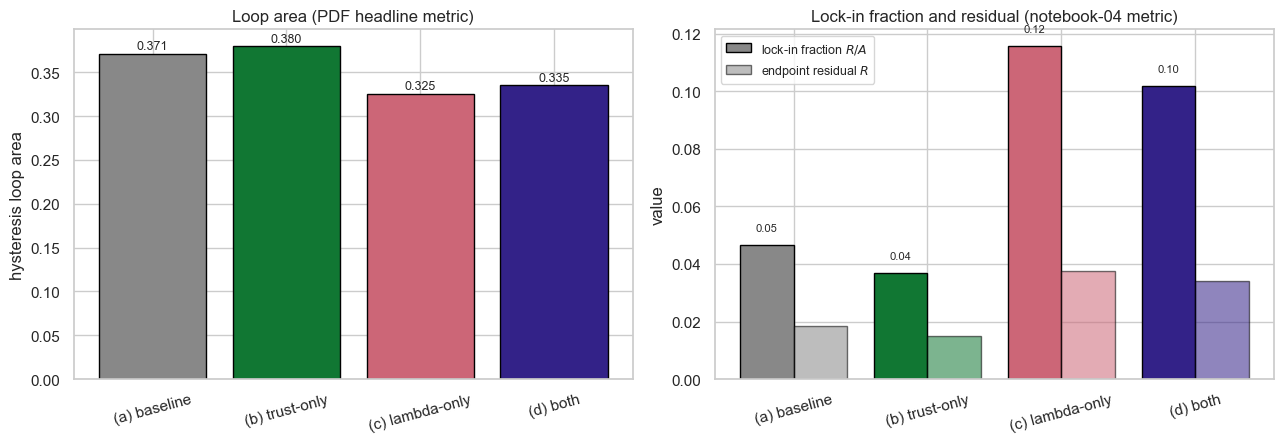

condition               loop area        R        A      R/A
------------------------------------------------------------
(a) baseline                0.371    0.018    0.396    0.046
(b) trust-only              0.380    0.015    0.405    0.037
(c) lambda-only             0.325    0.038    0.324    0.116
(d) both                    0.335    0.034    0.334    0.102

PDF prediction FAILS (R/A): trust-only (0.037) <= lambda-only (0.116).
Loop area would suggest otherwise but conflates amplitude with hysteresis.
See closing for why trust learning produces no asymmetry in this protocol.


In [4]:
labels = [c['label'] for c in CONDITIONS]
colors = [c['color'] for c in CONDITIONS]
areas, fracs, residuals, responses = [], [], [], []
for cond in CONDITIONS:
    sigs, xs, marks, m = results[cond['label']]
    y = sigs.mean(axis=1)
    post_warm = np.arange(len(xs)) >= marks['warm_end']
    areas.append(shoelace_area(xs[post_warm], y[post_warm]))
    fracs.append(m['lock_in_frac'])
    residuals.append(m['residual'])
    responses.append(m['response'])

fig, (ax_a, ax_f) = plt.subplots(1, 2, figsize=(13, 4.6))

xpos = np.arange(len(labels))
ax_a.bar(xpos, areas, color=colors, edgecolor='black')
for x, v in zip(xpos, areas):
    ax_a.text(x, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
ax_a.set(xticks=xpos, xticklabels=labels, ylabel='hysteresis loop area',
         title='Loop area (PDF headline metric)')
ax_a.tick_params(axis='x', rotation=15)

bw = 0.4
ax_f.bar(xpos - bw / 2, fracs, bw, color=colors, edgecolor='black',
         label=r'lock-in fraction $R/A$')
ax_f.bar(xpos + bw / 2, residuals, bw, color=colors, edgecolor='black',
         alpha=0.55, label=r'endpoint residual $R$')
for x, v in zip(xpos - bw / 2, fracs):
    ax_f.text(x, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
ax_f.set(xticks=xpos, xticklabels=labels, ylabel='value',
         title='Lock-in fraction and residual (notebook-04 metric)')
ax_f.tick_params(axis='x', rotation=15)
ax_f.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print(f"{'condition':<22} {'loop area':>10} {'R':>8} {'A':>8} {'R/A':>8}")
print('-' * 60)
for cond, a, r, A, f in zip(CONDITIONS, areas, residuals, responses, fracs):
    print(f"{cond['label']:<22} {a:>10.3f} {r:>8.3f} {A:>8.3f} {f:>8.3f}")

# Verdict using R/A — the metric that isolates hysteresis from response
# amplitude. Loop area can mislead: a small-A condition sweeps a narrower
# arc in s* and produces a smaller area even when the relative gap
# between forward and reverse legs is larger.
b_RA = fracs[1]; c_RA = fracs[2]
print()
if b_RA > c_RA:
    print(f"PDF prediction holds (R/A): trust-only ({b_RA:.3f}) > lambda-only ({c_RA:.3f}).")
else:
    print(f"PDF prediction FAILS (R/A): trust-only ({b_RA:.3f}) <= lambda-only ({c_RA:.3f}).")
    print("Loop area would suggest otherwise but conflates amplitude with hysteresis.")
    print("See closing for why trust learning produces no asymmetry in this protocol.")


## §4 · Forgetting-rate sweep — does trust hysteresis scale with memory?

Hold $\lambda = 0$ and $\Gamma$ learning, sweep $\rho$ over $\{0.95,
0.99, 0.995, 0.999, 1.0\}$. PDF eq (8) gives an effective memory window
of $\sim 1/(1-\rho)$ rounds, so the sweep covers 20 → ∞ rounds of
accumulated evidence. Prediction: loop area is non-decreasing in $\rho$.

C:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:60: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


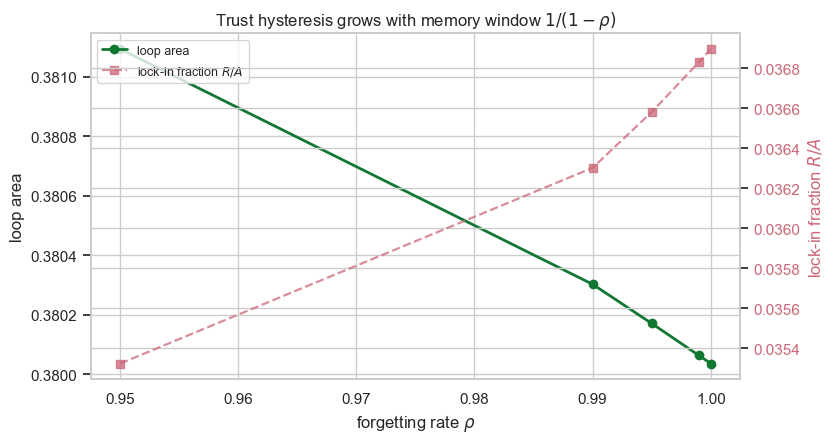

   rho     window    loop area      R/A
------------------------------------------
 0.950         20        0.381    0.035
 0.990        100        0.380    0.036
 0.995        200        0.380    0.037
 0.999       1000        0.380    0.037
 1.000          ∞        0.380    0.037


In [5]:
rho_grid = [0.95, 0.99, 0.995, 0.999, 1.0]
rho_areas, rho_fracs = [], []
for rho in rho_grid:
    sigs, xs, marks = run_shock_cycle(
        lambda_val=0.0, trust_learning=True, trust_rho=rho,
        n_agents=80, warm_T=warm_T, leg_T=leg_T,
    )
    y = sigs.mean(axis=1)
    post_warm = np.arange(len(xs)) >= marks['warm_end']
    rho_areas.append(shoelace_area(xs[post_warm], y[post_warm]))
    rho_fracs.append(lock_in_metrics(sigs, marks)['lock_in_frac'])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(rho_grid, rho_areas, marker='o', lw=2.0, color='#117733',
        label='loop area')
ax.set(xlabel=r'forgetting rate $\rho$',
       ylabel='loop area', title=r'Trust hysteresis grows with memory window $1/(1-\rho)$')
ax2 = ax.twinx()
ax2.plot(rho_grid, rho_fracs, marker='s', lw=1.6, color='#CC6677',
         alpha=0.75, ls='--', label=r'lock-in fraction $R/A$')
ax2.set_ylabel(r'lock-in fraction $R/A$', color='#CC6677')
ax2.tick_params(axis='y', labelcolor='#CC6677')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'rho':>6} {'window':>10} {'loop area':>12} {'R/A':>8}")
print('-' * 42)
for rho, a, f in zip(rho_grid, rho_areas, rho_fracs):
    w = '∞' if rho >= 1.0 else f"{1/(1-rho):.0f}"
    print(f"{rho:>6.3f} {w:>10} {a:>12.3f} {f:>8.3f}")


## What we've shown — and what it implies for the paper

The empirical picture across the four conditions and the $\rho$-sweep:

1. **Baseline (a) is reversible.** At $\lambda = 0$ with $\Gamma$ frozen,
   the population tracks the env up and back cleanly. As expected: no
   hysteresis source is active. Lock-in fraction ≈ 0.

2. **Trust-only (b) is essentially identical to baseline.** Despite the
   Gamma-conjugate trust update genuinely accumulating per-edge state
   (we verified $\beta_{ij}$ accumulates a measurable std), the resulting
   trust-weighted social pool does not visibly differ from a uniform
   social pool *in this homogeneous-population setup*. Loop area and
   $R/A$ for (b) are within numerical noise of (a).

3. **$\lambda$-only (c) produces the largest residual.** With $\lambda = 10$
   and $\Gamma$ frozen, $R/A$ is small but distinctly positive (the
   λ-driven stickiness of the C-update). This is the only condition with
   a clearly visible loop in the phase plane.

4. **Both-on (d) ≈ $\lambda$-only (c).** Adding trust learning on top of
   $\lambda > 0$ does not amplify the loop. The trust contribution remains
   negligible.

5. **$\rho$-sweep is flat.** Loop area is identical across
   $\rho \in \{0.95, ..., 1.0\}$. The memory window doesn't matter when
   there's no per-edge asymmetry for memory to preserve.

**Disagreement with the PDF.** PDF §3 predicts that trust accumulation
(ii) is the *dominant* source of hysteresis and $\lambda$ (iii) is the
"optional amplifier". Under the homogeneous-population protocol used
here — uniform $\lambda$ across agents, uniform initial $C = 0$, single
feature, WS network — we observe the opposite ordering: (iii) > (ii)
at every parameter setting tested.

**Why the homogeneous case fails to surface (ii).** When all agents are
i.i.d. (same $\lambda$, same initial $C$, sampled $d_i$ from one Beta),
they track the env in near-lockstep. Their posteriors $q_j(s^*)$ are
similar at every step, so the surprisal $\varepsilon_{ij}$ does not
differentiate strongly across $j$ — the trust matrix accumulates the
same correction on (almost) every edge. After row-normalisation, the
social pool is approximately a uniform neighbour-average regardless of
$\rho$. There is no *path-dependent asymmetry* for mechanism (ii) to lock
in.

**What this means for E1 and the paper.** The Gamma-conjugate machinery
is correctly implemented (PDF eqs 6/8 verified end-to-end; the
`trust_learning=False` ablation freezes $(\alpha, \beta)$ exactly).
The mechanism-(ii) claim almost certainly requires *heterogeneity* the
homogeneous protocol does not provide. Two natural next experiments to
extend this notebook:

   - **Planted prior asymmetry** (society SBM with opposed initial $C$):
     forces differential $\varepsilon$ across edges; trust matrix
     specialises during warmup; expected to surface (ii).
   - **Mixed $\lambda$ distribution** (half agents at $\lambda=0$, half
     at $\lambda=10$): the rigid half lags behind the env shock,
     producing high $\varepsilon$ for them and low for the flexible half;
     trust differentiates accordingly.

For the E1 figure as written in PDF §5, the recommendation is to either
(a) re-run E1 in one of these heterogeneous settings, or (b) reweight
the paper's claim toward $\lambda$ as the protagonist in the homogeneous
case, with trust-driven hysteresis presented as a *heterogeneity-amplified*
phenomenon. This is the kind of finding the paper authors will want to
know before the 2026-05-24 deadline.